In [2]:
# %pip install -q -U tabpfn-client scikit-learn pandas numpy matplotlib

%pip install -q "numpy>=1.25,<2.3"

%pip install -q tabpfn-client scikit-learn pandas matplotlib "numpy>=1.25,<2.3"


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss

SEED, THRESHOLD = 42, 0.50
pd.set_option("display.max_columns", 25)

In [4]:
credit = fetch_openml(name="credit-g", version=1, as_frame=True)
X = credit.data.copy()
labels = credit.target.astype(str)
assert set(labels.unique()) == {"good", "bad"}, "Unexpected target labels."
y = labels.eq("bad").astype(int).rename("bad_credit")

print(f"Dataset: {len(X):,} records × {X.shape[1]} features")
print("Target: 0 = good credit, 1 = bad credit")
print("Features:", X.columns.tolist())
display(y.value_counts().rename(index={0: "good", 1: "bad"}).to_frame("records"))
display(X.head())

Dataset: 1,000 records × 20 features
Target: 0 = good credit, 1 = bad credit
Features: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker']


,records
bad_credit,
good,700
bad,300


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
assert set(X_train.index).isdisjoint(X_test.index)
assert {"credit_amount", "duration"}.issubset(X.columns)

print(f"Training: {len(X_train)} | Test: {len(X_test)}")
display(X_train[["credit_amount", "duration"]].describe())

Training: 800 | Test: 200


,credit_amount,duration
count,800.00000,800.000000
mean,3189.59125,20.770000
std,2673.54737,11.817325
min,276.00000,4.000000
25%,1353.00000,12.000000
50%,2317.00000,18.000000
75%,3933.00000,24.000000
max,15945.00000,60.000000


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
assert set(X_train.index).isdisjoint(X_test.index)
assert {"credit_amount", "duration"}.issubset(X.columns)

print(f"Training: {len(X_train)} | Test: {len(X_test)}")
display(X_train[["credit_amount", "duration"]].describe())

Training: 800 | Test: 200


,credit_amount,duration
count,800.00000,800.000000
mean,3189.59125,20.770000
std,2673.54737,11.817325
min,276.00000,4.000000
25%,1353.00000,12.000000
50%,2317.00000,18.000000
75%,3933.00000,24.000000
max,15945.00000,60.000000


In [ ]:
tabpfn_sk_s2hHnfrSkoGgXBnRG79-QpD3AuUg7mi4EVUAUajP5wg

In [7]:
if not os.environ.get("TABPFN_TOKEN"):
    os.environ["TABPFN_TOKEN"] = getpass.getpass("Prior Labs API key: ").strip()
assert os.environ.get("TABPFN_TOKEN"), "An API key is required."

from tabpfn_client import TabPFNClassifier

In [8]:
model = TabPFNClassifier()
model.fit(X_train, y_train)

bad_class_idx = list(model.classes_).index(1)
smoke_probs = np.asarray(model.predict_proba(X_test.iloc[:5]))
assert smoke_probs.shape == (5, 2), f"Unexpected shape: {smoke_probs.shape}"
assert np.isfinite(smoke_probs).all()
assert np.allclose(smoke_probs.sum(axis=1), 1, atol=1e-5)

display(pd.DataFrame({
    "actual_bad_credit": y_test.iloc[:5],
    "predicted_bad_probability": smoke_probs[:, bad_class_idx]
}))
print("TabPFN inference check passed.")

,actual_bad_credit,predicted_bad_probability
30,0,0.235673
128,0,0.132558
289,1,0.686914
216,0,0.545855
966,1,0.207299


TabPFN inference check passed.


In [9]:
p_bad = np.asarray(model.predict_proba(X_test))[:, bad_class_idx]
baseline = X_test[["credit_amount", "duration"]].copy()
baseline["actual_bad_credit"] = y_test
baseline["p_bad"] = p_bad
baseline["predicted_bad_credit"] = (p_bad >= THRESHOLD).astype(int)

print(f"ROC-AUC: {roc_auc_score(y_test, p_bad):.3f}")
print(f"Accuracy at {THRESHOLD:.2f}: {accuracy_score(y_test, baseline.predicted_bad_credit):.3f}")
print(f"Brier score: {brier_score_loss(y_test, p_bad):.3f}")
print(f"Predicted high-risk records: {(p_bad >= THRESHOLD).sum()}/{len(p_bad)}")
display(baseline.sort_values("p_bad", ascending=False).head(10))

ROC-AUC: 0.828
Accuracy at 0.50: 0.795
Brier score: 0.146
Predicted high-risk records: 45/200


,credit_amount,duration,actual_bad_credit,p_bad,predicted_bad_credit
11,4308,48,1,0.823243,1
522,7119,48,1,0.814306,1
832,11816,45,1,0.805751,1
853,1442,18,1,0.793590,1
831,1216,18,1,0.788134,1
818,15857,36,0,0.780407,1
528,2302,36,1,0.755978,1
917,14896,6,1,0.745823,1
938,6288,60,1,0.733975,1
751,976,18,1,0.733011,1


In [10]:
FEATURES = ["credit_amount", "duration"]
AMOUNT_FRACTIONS = np.linspace(0.05, 0.75, 15)
MIN_AMOUNT = float(X_train.credit_amount.min())
DURATION_VALUES = np.sort(X_train.duration.unique())

def candidate_edits(row):
    edits = []
    original_amount = float(row.credit_amount)
    amounts = np.unique(np.round(original_amount * (1 - AMOUNT_FRACTIONS)))
    for value in amounts:
        if MIN_AMOUNT <= value < original_amount:
            edits.append(("credit_amount", original_amount, float(value)))
    for value in DURATION_VALUES:
        if value < float(row.duration):
            edits.append(("duration", float(row.duration), float(value)))
    return edits

In [11]:
candidate_rows, metadata = [], []
for record_id, row in X_test.loc[baseline.p_bad >= THRESHOLD].iterrows():
    for feature, old_value, new_value in candidate_edits(row):
        modified = row.copy()
        modified[feature] = new_value
        candidate_rows.append(modified)
        metadata.append({
            "record_id": record_id, "feature": feature,
            "old_value": old_value, "new_value": new_value,
            "relative_reduction": (old_value - new_value) / old_value
        })

assert candidate_rows, "No eligible candidate edits were generated."
X_candidates = pd.DataFrame(candidate_rows, columns=X_test.columns).astype(X_test.dtypes.to_dict())
probe_results = pd.DataFrame(metadata)
print(f"Scoring {len(X_candidates):,} candidate edits.")

BATCH_SIZE = 250
candidate_probs = []
for start in range(0, len(X_candidates), BATCH_SIZE):
    batch = X_candidates.iloc[start:start + BATCH_SIZE]
    candidate_probs.extend(np.asarray(model.predict_proba(batch))[:, bad_class_idx])
    print(f"Scored {min(start + BATCH_SIZE, len(X_candidates))}/{len(X_candidates)}")

probe_results["baseline_p_bad"] = probe_results.record_id.map(baseline.p_bad)
probe_results["modified_p_bad"] = candidate_probs
probe_results["delta_p_bad"] = probe_results.modified_p_bad - probe_results.baseline_p_bad
probe_results["flipped"] = probe_results.modified_p_bad < THRESHOLD
display(probe_results.head())

Scoring 1,485 candidate edits.
Scored 250/1485
Scored 500/1485
Scored 750/1485
Scored 1000/1485
Scored 1250/1485
Scored 1485/1485


,record_id,feature,old_value,new_value,relative_reduction,baseline_p_bad,modified_p_bad,delta_p_bad,flipped
0,289,credit_amount,1024.0,307.0,0.700195,0.686914,0.653160,-0.033754,False
1,289,credit_amount,1024.0,358.0,0.650391,0.686914,0.660785,-0.026129,False
2,289,credit_amount,1024.0,410.0,0.599609,0.686914,0.662577,-0.024337,False
3,289,credit_amount,1024.0,461.0,0.549805,0.686914,0.672587,-0.014326,False
4,289,credit_amount,1024.0,512.0,0.500000,0.686914,0.672891,-0.014023,False


In [12]:
successful = probe_results.loc[probe_results.flipped].sort_values(
    ["record_id", "relative_reduction", "modified_p_bad", "feature"]
)
best_flips = successful.drop_duplicates("record_id").set_index("record_id")
summary = baseline.loc[baseline.p_bad >= THRESHOLD].join(
    best_flips[["feature", "old_value", "new_value", "relative_reduction", "modified_p_bad"]]
)
summary["flip_found"] = summary.feature.notna()

print(f"Single-feature flips found: {summary.flip_found.sum()}/{len(summary)}")
display(summary.sort_values(["flip_found", "relative_reduction"], ascending=[False, True]).head(15))

Single-feature flips found: 29/45


,credit_amount,duration,actual_bad_credit,p_bad,predicted_bad_credit,feature,old_value,new_value,relative_reduction,modified_p_bad,flip_found
338,4169,24,0,0.529419,1,duration,24.0,22.0,0.083333,0.468905,True
89,1108,12,1,0.523880,1,duration,12.0,11.0,0.083333,0.458513,True
261,1603,24,0,0.501603,1,duration,24.0,22.0,0.083333,0.452788,True
194,3031,45,1,0.511979,1,duration,45.0,40.0,0.111111,0.496349,True
1,5951,48,1,0.543003,1,duration,48.0,42.0,0.125000,0.492249,True
944,1845,15,0,0.512180,1,duration,15.0,13.0,0.133333,0.495011,True
216,3104,18,0,0.545915,1,duration,18.0,15.0,0.166667,0.494689,True
395,11760,39,0,0.563310,1,credit_amount,11760.0,9408.0,0.200000,0.496099,True
746,2511,15,0,0.574741,1,duration,15.0,11.0,0.266667,0.491301,True
548,626,12,1,0.599571,1,duration,12.0,8.0,0.333333,0.464235,True


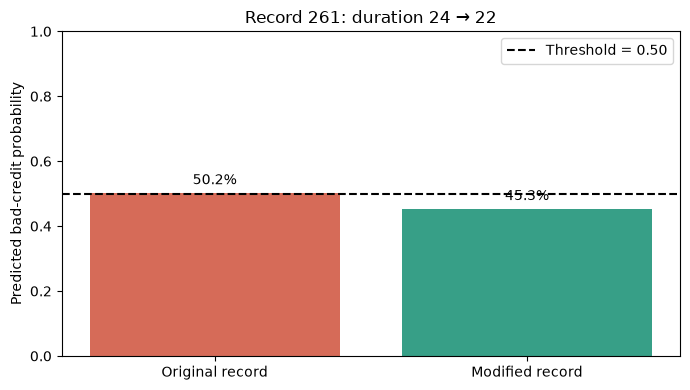

Relative reduction: 8.3%


In [13]:
if best_flips.empty:
    print("No decision flips found within the tested edits. Keep this result; do not force an example.")
else:
    example_id = best_flips.sort_values(["relative_reduction", "modified_p_bad"]).index[0]
    example = best_flips.loc[example_id]
    values = [example.baseline_p_bad, example.modified_p_bad]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(["Original record", "Modified record"], values, color=["#d66b58", "#379f87"])
    ax.axhline(THRESHOLD, color="black", linestyle="--", label=f"Threshold = {THRESHOLD:.2f}")
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in values], padding=4)
    ax.set(ylim=(0, 1), ylabel="Predicted bad-credit probability",
           title=f"Record {example_id}: {example.feature} {example.old_value:g} → {example.new_value:g}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Relative reduction: {example.relative_reduction:.1%}")

In [14]:
assert not best_flips.empty, "No successful edits available for stability testing."
N_REPEATS, TRAIN_FRACTION = 10, 0.80
selected_ids = best_flips.index.tolist()
original_records = X_test.loc[selected_ids].copy()
modified_records = original_records.copy()

for record_id, edit in best_flips.iterrows():
    modified_records.at[record_id, edit.feature] = edit.new_value

paired_records = pd.concat([original_records, modified_records], ignore_index=True)
print(f"Checking {len(selected_ids)} fixed edits across {N_REPEATS} training subsets.")

Checking 29 fixed edits across 10 training subsets.


In [15]:
stability_rows = []
for repeat in range(N_REPEATS):
    subset_X, _, subset_y, _ = train_test_split(
        X_train, y_train, train_size=TRAIN_FRACTION, stratify=y_train, random_state=SEED + 100 + repeat
    )
    repeat_model = TabPFNClassifier()
    repeat_model.fit(subset_X, subset_y)
    class_idx = list(repeat_model.classes_).index(1)
    probabilities = np.asarray(repeat_model.predict_proba(paired_records))[:, class_idx]
    original_p, modified_p = probabilities[:len(selected_ids)], probabilities[len(selected_ids):]
    for record_id, before, after in zip(selected_ids, original_p, modified_p):
        stability_rows.append({
            "repeat": repeat + 1, "record_id": record_id,
            "original_p_bad": before, "modified_p_bad": after,
            "original_high_risk": before >= THRESHOLD,
            "modified_low_risk": after < THRESHOLD,
            "retained_flip": (before >= THRESHOLD) and (after < THRESHOLD)
        })
    print(f"Completed subset {repeat + 1}/{N_REPEATS}")

stability_runs = pd.DataFrame(stability_rows)

Completed subset 1/10
Completed subset 2/10
Completed subset 3/10
Completed subset 4/10
Completed subset 5/10
Completed subset 6/10
Completed subset 7/10
Completed subset 8/10
Completed subset 9/10
Completed subset 10/10


In [16]:
stability_summary = stability_runs.groupby("record_id").agg(
    repeats=("repeat", "count"),
    original_high_risk_count=("original_high_risk", "sum"),
    modified_low_risk_count=("modified_low_risk", "sum"),
    retained_flip_count=("retained_flip", "sum"),
    mean_original_p=("original_p_bad", "mean"),
    mean_modified_p=("modified_p_bad", "mean")
)
stability_summary["retained_flip_rate"] = stability_summary.retained_flip_count / stability_summary.repeats
stability_summary["conditional_flip_rate"] = (
    stability_summary.retained_flip_count / stability_summary.original_high_risk_count.replace(0, np.nan)
)
stability_summary = best_flips[["feature", "old_value", "new_value", "relative_reduction"]].join(stability_summary)
display(stability_summary.sort_values("retained_flip_rate", ascending=False))

,feature,old_value,new_value,relative_reduction,repeats,original_high_risk_count,modified_low_risk_count,retained_flip_count,mean_original_p,mean_modified_p,retained_flip_rate,conditional_flip_rate
record_id,,,,,,,,,,,,
840,duration,36.0,22.0,0.388889,10,10,10,10,0.585106,0.453892,1.0,1.000000
953,credit_amount,10974.0,2744.0,0.749954,10,9,9,8,0.557071,0.425411,0.8,0.888889
570,duration,24.0,11.0,0.541667,10,10,7,7,0.663917,0.488652,0.7,0.700000
917,credit_amount,14896.0,3724.0,0.750000,10,10,7,7,0.691424,0.466368,0.7,0.700000
289,duration,24.0,11.0,0.541667,10,10,7,7,0.637184,0.462070,0.7,0.700000
998,duration,45.0,15.0,0.666667,10,10,7,7,0.666152,0.480492,0.7,0.700000
751,duration,18.0,4.0,0.777778,10,10,7,7,0.714522,0.464700,0.7,0.700000
431,credit_amount,11328.0,6797.0,0.399982,10,10,6,6,0.594089,0.481049,0.6,0.600000
887,credit_amount,15672.0,6269.0,0.599987,10,10,6,6,0.676428,0.491695,0.6,0.600000


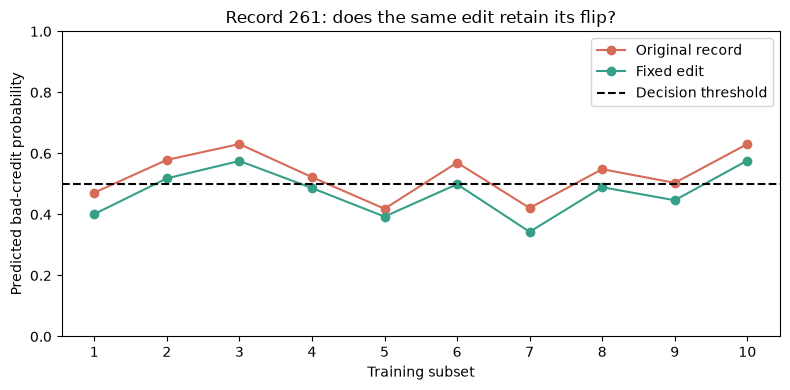

Original remained high risk: 7/10
Modified record was low risk: 7/10
Paired flips retained: 4/10


In [17]:
example_runs = stability_runs.loc[stability_runs.record_id == example_id]
example_stats = stability_summary.loc[example_id]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(example_runs["repeat"], example_runs.original_p_bad, "o-", label="Original record", color="#d66b58")
ax.plot(example_runs["repeat"], example_runs.modified_p_bad, "o-", label="Fixed edit", color="#379f87")
ax.axhline(THRESHOLD, color="black", linestyle="--", label="Decision threshold")
ax.set(xlabel="Training subset", ylabel="Predicted bad-credit probability", ylim=(0, 1),
       xticks=range(1, N_REPEATS + 1), title=f"Record {example_id}: does the same edit retain its flip?")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Original remained high risk: {int(example_stats.original_high_risk_count)}/{N_REPEATS}")
print(f"Modified record was low risk: {int(example_stats.modified_low_risk_count)}/{N_REPEATS}")
print(f"Paired flips retained: {int(example_stats.retained_flip_count)}/{N_REPEATS}")

In [18]:
from scipy.special import expit

SYNTH_SEEDS = [42, 43, 44]
SYNTH_FEATURES = ["signal_1", "signal_2", "independent_noise", "correlated_proxy"]
SYNTH_SHIFTS = [-0.50, -0.25, 0.25, 0.50]

def true_probability(frame):
    return expit(-0.3 + 1.6 * frame["signal_1"] + 0.9 * frame["signal_2"] - 0.8 * frame["signal_2"]**2)

def make_synthetic(seed, n=1000):
    rng = np.random.default_rng(seed)
    frame = pd.DataFrame({
        "signal_1": rng.uniform(-2, 2, n),
        "signal_2": rng.uniform(-2, 2, n),
        "independent_noise": rng.uniform(-2, 2, n)
    })
    frame["correlated_proxy"] = 0.8 * frame.signal_1 + rng.normal(0, 0.6, n)
    target = pd.Series(rng.binomial(1, true_probability(frame)), index=frame.index)
    return frame, target

In [19]:
synthetic_results, synthetic_baselines = [], []
for seed in SYNTH_SEEDS:
    syn_X, syn_y = make_synthetic(seed)
    syn_train, syn_test, syn_y_train, syn_y_test = train_test_split(
        syn_X, syn_y, test_size=0.20, stratify=syn_y, random_state=seed
    )
    syn_model = TabPFNClassifier()
    syn_model.fit(syn_train, syn_y_train)
    class_idx = list(syn_model.classes_).index(1)
    records = syn_test.sample(n=40, random_state=seed)
    variants, metadata = [], []

    for record_id, row in records.iterrows():
        for feature in SYNTH_FEATURES:
            for shift in SYNTH_SHIFTS:
                new_value = row[feature] + shift
                if syn_train[feature].min() <= new_value <= syn_train[feature].max():
                    changed = row.copy()
                    changed[feature] = new_value
                    variants.append(changed)
                    metadata.append({"seed": seed, "record_id": record_id, "feature": feature, "shift": shift})

    variants = pd.DataFrame(variants, columns=syn_X.columns)
    inputs = pd.concat([records, variants], ignore_index=True)
    predicted = np.asarray(syn_model.predict_proba(inputs))[:, class_idx]
    baseline_pred = pd.Series(predicted[:len(records)], index=records.index)
    baseline_true = true_probability(records)
    result = pd.DataFrame(metadata)
    result["estimated_delta"] = predicted[len(records):] - result.record_id.map(baseline_pred).to_numpy()
    result["true_delta"] = true_probability(variants).to_numpy() - result.record_id.map(baseline_true).to_numpy()
    result["absolute_error"] = np.abs(result.estimated_delta - result.true_delta)
    synthetic_results.append(result)
    synthetic_baselines.append({
        "seed": seed,
        "probability_mae": np.mean(np.abs(baseline_pred.to_numpy() - baseline_true.to_numpy()))
    })
    print(f"Seed {seed}: evaluated {len(result)} edits.")

synthetic_results = pd.concat(synthetic_results, ignore_index=True)
display(pd.DataFrame(synthetic_baselines))

Seed 42: evaluated 598 edits.
Seed 43: evaluated 584 edits.
Seed 44: evaluated 593 edits.


,seed,probability_mae
0,42,0.023413
1,43,0.038873
2,44,0.034669


In [20]:
def summarize_effects(group):
    informative = group.true_delta.abs() > 0.01
    return pd.Series({
        "tested_edits": len(group),
        "effect_MAE": group.absolute_error.mean(),
        "effect_RMSE": np.sqrt(np.mean((group.estimated_delta - group.true_delta)**2)),
        "mean_absolute_model_delta": group.estimated_delta.abs().mean(),
        "sign_agreement": np.mean(
            np.sign(group.loc[informative, "estimated_delta"]) == np.sign(group.loc[informative, "true_delta"])
        ) if informative.any() else np.nan
    })

effect_metrics = pd.DataFrame({feature: summarize_effects(group)
                              for feature, group in synthetic_results.groupby("feature")}).T
display(effect_metrics.round(4))

,tested_edits,effect_MAE,effect_RMSE,mean_absolute_model_delta,sign_agreement
correlated_proxy,474.0,0.0147,0.0236,0.0147,NaN
independent_noise,437.0,0.0099,0.0187,0.0099,NaN
signal_1,429.0,0.0218,0.0311,0.0819,0.9975
signal_2,435.0,0.0200,0.0309,0.0737,0.9720


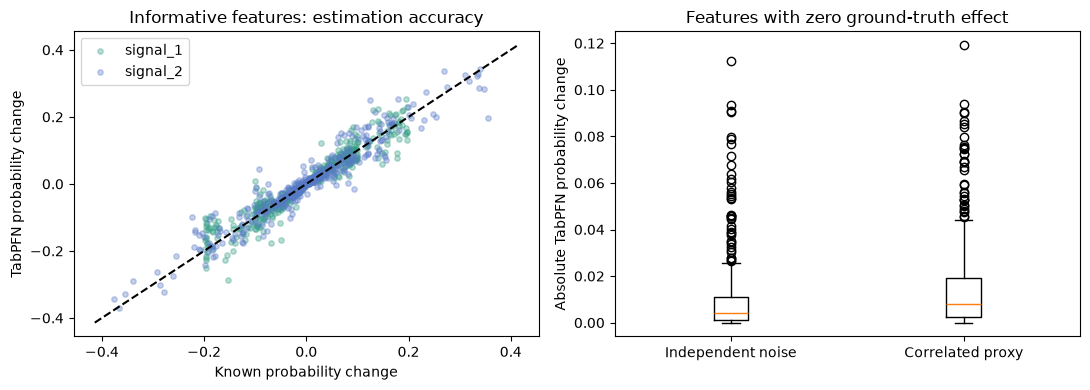

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = {"signal_1": "#379f87", "signal_2": "#587ac7"}

for feature, color in colors.items():
    group = synthetic_results.loc[synthetic_results.feature == feature]
    axes[0].scatter(group.true_delta, group.estimated_delta, s=15, alpha=0.35, label=feature, color=color)

signal_results = synthetic_results.loc[synthetic_results.feature.isin(colors)]
limit = max(signal_results.true_delta.abs().max(), signal_results.estimated_delta.abs().max()) * 1.1
axes[0].plot([-limit, limit], [-limit, limit], "--", color="black")
axes[0].set(xlabel="Known probability change", ylabel="TabPFN probability change",
            title="Informative features: estimation accuracy")
axes[0].legend()

zero_features = ["independent_noise", "correlated_proxy"]
zero_values = [synthetic_results.loc[synthetic_results.feature == feature, "estimated_delta"].abs().to_numpy()
               for feature in zero_features]
axes[1].boxplot(zero_values)
axes[1].set_xticks([1, 2], ["Independent noise", "Correlated proxy"])
axes[1].set(ylabel="Absolute TabPFN probability change",
            title="Features with zero ground-truth effect")
plt.tight_layout()
plt.show()

In [23]:
from pathlib import Path
import pickle

SAVE_DIR = Path("decision_probe_results")
SAVE_DIR.mkdir(exist_ok=True)
names = [
    "X_train", "X_test", "y_train", "y_test", "baseline", "probe_results",
    "best_flips", "summary", "stability_runs", "stability_summary",
    "synthetic_results", "synthetic_baselines", "effect_metrics",
    "SEED", "THRESHOLD", "FEATURES", "N_REPEATS", "example_id"
]
missing = [name for name in names if name not in globals()]
assert not missing, f"Missing variables: {missing}"
saved_state = {name: globals()[name] for name in names}

with (SAVE_DIR / "demo_state.pkl").open("wb") as file:
    pickle.dump(saved_state, file, protocol=pickle.HIGHEST_PROTOCOL)

for name in ["baseline", "probe_results", "summary", "stability_runs", "stability_summary", "synthetic_results", "effect_metrics"]:
    saved_state[name].to_csv(SAVE_DIR / f"{name}.csv")

with (SAVE_DIR / "demo_state.pkl").open("rb") as file:
    restored = pickle.load(file)
pd.testing.assert_frame_equal(restored["probe_results"], probe_results)
pd.testing.assert_frame_equal(restored["stability_summary"], stability_summary)
print("Saved and reload verified:", (SAVE_DIR / "demo_state.pkl").resolve())

Saved and reload verified: /homes/mxqasim/Hackathon/decision_probe_results/demo_state.pkl
